In [1]:
# =======================
# 1. IMPORT LIBRARIES
# =======================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)


In [2]:
# =======================
# 2. LOAD DATASET
# =======================

df = pd.read_excel(
    r"C:\Users\ss295\Desktop\desktop\Data Science\Intership & Certificates\Tata micro intership\Delinquency_prediction_dataset.xlsx"
)

print("Dataset Shape:", df.shape)

Dataset Shape: (500, 19)


In [3]:
# =======================
# 3. DROP CUSTOMER ID
# =======================

df.drop('Customer_ID', axis=1, inplace=True)

In [4]:
# =======================
# 4. FEATURES & TARGET
# =======================

X = df.drop('Delinquent_Account', axis=1)
y = df['Delinquent_Account']

In [5]:
# =======================
# 5. NUMERICAL & CATEGORICAL COLUMNS
# =======================

numerical_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=['object']
).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)


Numerical Columns:
['Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure']

Categorical Columns:
['Employment_Status', 'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']


C:\Users\ss295\AppData\Local\Temp\ipykernel_16104\2595079968.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [6]:
# =======================
# 6. PREPROCESSING
# =======================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first',
                              handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [7]:
# =======================
# 7. TRAIN TEST SPLIT
# =======================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
# =======================
# 8. MODEL PIPELINE
# =======================

model = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

In [9]:
# =======================
# 9. TRAIN MODEL
# =======================

model.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")



Model Training Completed Successfully!


In [10]:
# =======================
# 10. PREDICTIONS
# =======================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [11]:
# =======================
# 11. MODEL EVALUATION
# =======================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n========== MODEL PERFORMANCE ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")


========== MODEL PERFORMANCE ==========
Accuracy  : 0.5200
Precision : 0.1190
Recall    : 0.3125
F1 Score  : 0.1724
ROC AUC   : 0.4330


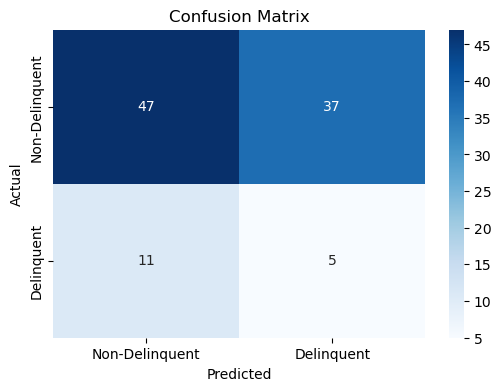

In [12]:
# =======================
# 13. CONFUSION MATRIX
# =======================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Delinquent',
                 'Delinquent'],
    yticklabels=['Non-Delinquent',
                 'Delinquent']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

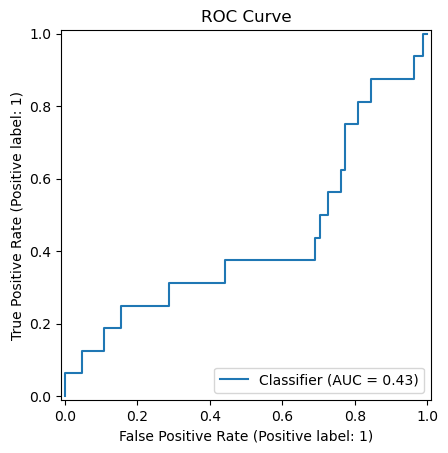

In [13]:
# =======================
# 14. ROC CURVE
# =======================

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()

In [14]:
# =======================
# 15. FEATURE IMPORTANCE
# =======================

feature_names = model.named_steps[
    'preprocessor'
].get_feature_names_out()

coefficients = model.named_steps[
    'classifier'
].coef_[0]

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importance['Absolute_Value'] = abs(
    importance['Coefficient']
)

importance = importance.sort_values(
    by='Absolute_Value',
    ascending=False
)

print("\nTop 10 Important Features:\n")
print(
    importance[['Feature',
                'Coefficient']]
    .head(10)
)




Top 10 Important Features:

                            Feature  Coefficient
15   cat__Credit_Card_Type_Standard    -0.874973
28             cat__Month_4_On-time    -0.730806
22             cat__Month_1_On-time     0.701412
21              cat__Month_1_Missed     0.502481
8   cat__Employment_Status_Employed     0.446495
27              cat__Month_4_Missed    -0.444370
19           cat__Location_New York    -0.436170
32             cat__Month_6_On-time     0.412198
23              cat__Month_2_Missed    -0.338423
31              cat__Month_6_Missed     0.332411


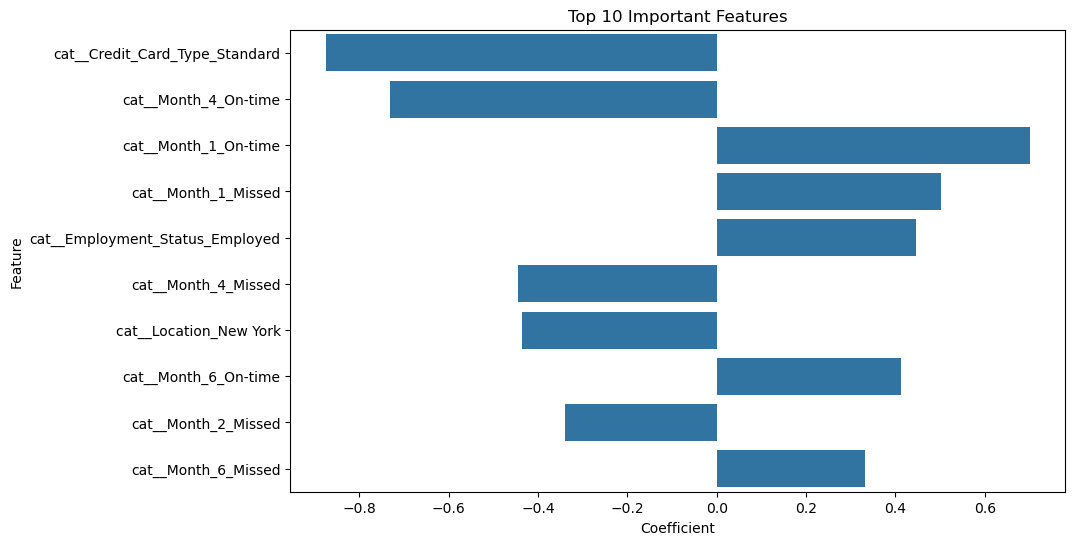

In [15]:
# Plot Feature Importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Coefficient',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.show()